In [1]:
import re
from collections import Counter

import nltk
import pandas as pd
import matplotlib.pyplot as plt

from nltk.corpus import movie_reviews
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
from nltk.stem import WordNetLemmatizer

pd.set_option("display.max_colwidth", 150)

In [2]:
nltk.download("movie_reviews")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tagge

True

In [3]:
positive_ids = movie_reviews.fileids("pos")[:100]
negative_ids = movie_reviews.fileids("neg")[:100]

rows = []

for fileid in positive_ids:
    rows.append({
        "fileid": fileid,
        "category": "pos",
        "text": movie_reviews.raw(fileid)
    })

for fileid in negative_ids:
    rows.append({
        "fileid": fileid,
        "category": "neg",
        "text": movie_reviews.raw(fileid)
    })

df = pd.DataFrame(rows)

print(df.shape)
df.head()

(200, 3)


,fileid,category,text
0,pos/cv000_29590.txt,pos,"films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kid..."
1,pos/cv001_18431.txt,pos,"every now and then a movie comes along from a suspect studio , with every indication that it will be a stinker , and to everybody's surprise ( per..."
2,pos/cv002_15918.txt,pos,"you've got mail works alot better than it deserves to . \nin order to make the film a success , all they had to do was cast two extremely popular ..."
3,pos/cv003_11664.txt,pos,""" jaws "" is a rare film that grabs your attention before it shows you a single image on screen . \nthe movie opens with blackness , and only dist..."
4,pos/cv004_11636.txt,pos,moviemaking is a lot like being the general manager of an nfl team in the post-salary cap era -- you've got to know how to allocate your resources...


In [4]:
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    elif treebank_tag.startswith("V"):
        return wordnet.VERB
    elif treebank_tag.startswith("N"):
        return wordnet.NOUN
    elif treebank_tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [5]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [6]:
def preprocess_basic(text):

    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)

    return tokens

In [7]:
def preprocess_no_stopwords(text):

    tokens = preprocess_basic(text)

    tokens = [
        word
        for word in tokens
        if word not in stop_words and len(word) >= 3
    ]

    return tokens

In [9]:
def preprocess_lemmatized(text):

    tokens = preprocess_no_stopwords(text)
    tagged = pos_tag(tokens)
    lemmas = []

    for word, tag in tagged:
        pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos)
        lemmas.append(lemma)
    return lemmas

In [10]:
df["basic"] = df["text"].apply(preprocess_basic)

df["no_stopwords"] = df["text"].apply(preprocess_no_stopwords)

df["lemmatized"] = df["text"].apply(preprocess_lemmatized)

df.head()

,fileid,category,text,basic,no_stopwords,lemmatized
0,pos/cv000_29590.txt,pos,"films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kid...","[films, adapted, from, comic, books, have, had, plenty, of, success, whether, they, re, about, superheroes, batman, superman, spawn, or, geared, t...","[films, adapted, comic, books, plenty, success, whether, superheroes, batman, superman, spawn, geared, toward, kids, casper, arthouse, crowd, ghos...","[film, adapt, comic, book, plenty, success, whether, superheroes, batman, superman, spawn, gear, toward, kid, casper, arthouse, crowd, ghost, worl..."
1,pos/cv001_18431.txt,pos,"every now and then a movie comes along from a suspect studio , with every indication that it will be a stinker , and to everybody's surprise ( per...","[every, now, and, then, a, movie, comes, along, from, a, suspect, studio, with, every, indication, that, it, will, be, a, stinker, and, to, everyb...","[every, movie, comes, along, suspect, studio, every, indication, stinker, everybody, surprise, perhaps, even, studio, film, becomes, critical, dar...","[every, movie, come, along, suspect, studio, every, indication, stinker, everybody, surprise, perhaps, even, studio, film, become, critical, darli..."
2,pos/cv002_15918.txt,pos,"you've got mail works alot better than it deserves to . \nin order to make the film a success , all they had to do was cast two extremely popular ...","[you, ve, got, mail, works, alot, better, than, it, deserves, to, in, order, to, make, the, film, a, success, all, they, had, to, do, was, cast, t...","[got, mail, works, alot, better, deserves, order, make, film, success, cast, two, extremely, popular, attractive, stars, share, screen, two, hours...","[get, mail, work, alot, good, deserves, order, make, film, success, cast, two, extremely, popular, attractive, star, share, screen, two, hour, col..."
3,pos/cv003_11664.txt,pos,""" jaws "" is a rare film that grabs your attention before it shows you a single image on screen . \nthe movie opens with blackness , and only dist...","[jaws, is, a, rare, film, that, grabs, your, attention, before, it, shows, you, a, single, image, on, screen, the, movie, opens, with, blackness, ...","[jaws, rare, film, grabs, attention, shows, single, image, screen, movie, opens, blackness, distant, alien, like, underwater, sounds, comes, first...","[jaw, rare, film, grab, attention, show, single, image, screen, movie, open, blackness, distant, alien, like, underwater, sound, come, first, omin..."
4,pos/cv004_11636.txt,pos,moviemaking is a lot like being the general manager of an nfl team in the post-salary cap era -- you've got to know how to allocate your resources...,"[moviemaking, is, a, lot, like, being, the, general, manager, of, an, nfl, team, in, the, post, salary, cap, era, you, ve, got, to, know, how, to,...","[moviemaking, lot, like, general, manager, nfl, team, post, salary, cap, era, got, know, allocate, resources, every, dollar, spent, free, agent, d...","[moviemaking, lot, like, general, manager, nfl, team, post, salary, cap, era, get, know, allocate, resource, every, dollar, spend, free, agent, de..."


In [11]:
def preprocessing_statistics(tokens_column):

    all_tokens = []

    for tokens in tokens_column:
        all_tokens.extend(tokens)

    total_tokens = len(all_tokens)

    unique_tokens = len(set(all_tokens))

    top10 = Counter(all_tokens).most_common(10)

    return total_tokens, unique_tokens, top10

In [12]:
basic_total, basic_unique, basic_top = preprocessing_statistics(df["basic"])

nostop_total, nostop_unique, nostop_top = preprocessing_statistics(df["no_stopwords"])

lemma_total, lemma_unique, lemma_top = preprocessing_statistics(df["lemmatized"])

In [13]:
comparison_df = pd.DataFrame({
    "preprocessing": [
        "basic",
        "no_stopwords",
        "lemmatized"
    ],
    "total_tokens": [
        basic_total,
        nostop_total,
        lemma_total
    ],
    "unique_tokens": [
        basic_unique,
        nostop_unique,
        lemma_unique
    ],
    "top_3_words": [
        ", ".join([word for word, freq in basic_top[:3]]),
        ", ".join([word for word, freq in nostop_top[:3]]),
        ", ".join([word for word, freq in lemma_top[:3]])
    ]
})
comparison_df

,preprocessing,total_tokens,unique_tokens,top_3_words
0,basic,127933,13702,"the, a, and"
1,no_stopwords,66840,13457,"film, movie, one"
2,lemmatized,66840,11192,"film, movie, one"


In [14]:
positive_tokens = []
negative_tokens = []

for _, row in df.iterrows():
    if row["category"] == "pos":
        positive_tokens.extend(row["lemmatized"])
    else:
        negative_tokens.extend(row["lemmatized"])

In [15]:
positive_counter = Counter(positive_tokens)
negative_counter = Counter(negative_tokens)
top_pos = positive_counter.most_common(10)
top_neg = negative_counter.most_common(10)

print(top_pos)
print()
print(top_neg)

[('film', 564), ('movie', 285), ('one', 253), ('make', 210), ('like', 208), ('character', 205), ('get', 187), ('see', 170), ('time', 157), ('good', 130)]

[('film', 498), ('movie', 386), ('one', 274), ('like', 226), ('make', 216), ('character', 203), ('get', 202), ('even', 149), ('time', 136), ('bad', 134)]


In [16]:
csv_rows = []

for word, freq in top_pos:
    csv_rows.append({
        "category": "pos",
        "word": word,
        "frequency": freq
    })

for word, freq in top_neg:
    csv_rows.append({
        "category": "neg",
        "word": word,
        "frequency": freq
    })

top_words_df = pd.DataFrame(csv_rows)
top_words_df

,category,word,frequency
0,pos,film,564
1,pos,movie,285
2,pos,one,253
3,pos,make,210
4,pos,like,208
5,pos,character,205
6,pos,get,187
7,pos,see,170
8,pos,time,157
9,pos,good,130


In [17]:
top_words_df.to_csv(
    "movie_review_top_words.csv",
    index=False,
    encoding="utf-8"
)

print("CSV saved.")

CSV saved.


In [18]:
from collections import Counter

comparison = []

for name, column in [
    ("basic", "basic"),
    ("no_stopwords", "no_stopwords"),
    ("lemmatized", "lemmatized"),
]:

    all_tokens = []

    for tokens in df[column]:
        all_tokens.extend(tokens)

    counter = Counter(all_tokens)

    comparison.append({
        "preprocessing": name,
        "total_tokens": len(all_tokens),
        "unique_tokens": len(set(all_tokens)),
        "top_3_words": ", ".join(
            word for word, freq in counter.most_common(3)
        )
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,preprocessing,total_tokens,unique_tokens,top_3_words
0,basic,127933,13702,"the, a, and"
1,no_stopwords,66840,13457,"film, movie, one"
2,lemmatized,66840,11192,"film, movie, one"


In [19]:
for name, column in [
    ("basic", "basic"),
    ("no_stopwords", "no_stopwords"),
    ("lemmatized", "lemmatized"),
]:

    all_tokens = []

    for tokens in df[column]:
        all_tokens.extend(tokens)

    counter = Counter(all_tokens)

    print("=" * 50)
    print(name)
    print(counter.most_common(10))

basic
[('the', 7389), ('a', 3669), ('and', 3433), ('of', 3301), ('to', 3101), ('is', 2423), ('in', 2073), ('s', 1907), ('that', 1567), ('it', 1520)]
no_stopwords
[('film', 885), ('movie', 540), ('one', 516), ('like', 403), ('even', 242), ('time', 234), ('good', 231), ('character', 216), ('story', 214), ('get', 208)]
lemmatized
[('film', 1062), ('movie', 671), ('one', 527), ('like', 434), ('make', 426), ('character', 408), ('get', 389), ('see', 303), ('time', 293), ('good', 261)]


In [20]:
pos_tokens = []

for tokens in df[df["category"] == "pos"]["lemmatized"]:
    pos_tokens.extend(tokens)

pos_counter = Counter(pos_tokens)

pos_top10 = pos_counter.most_common(10)

pos_top10

[('film', 564),
 ('movie', 285),
 ('one', 253),
 ('make', 210),
 ('like', 208),
 ('character', 205),
 ('get', 187),
 ('see', 170),
 ('time', 157),
 ('good', 130)]

In [21]:
neg_tokens = []

for tokens in df[df["category"] == "neg"]["lemmatized"]:
    neg_tokens.extend(tokens)

neg_counter = Counter(neg_tokens)

neg_top10 = neg_counter.most_common(10)

neg_top10

[('film', 498),
 ('movie', 386),
 ('one', 274),
 ('like', 226),
 ('make', 216),
 ('character', 203),
 ('get', 202),
 ('even', 149),
 ('time', 136),
 ('bad', 134)]

In [22]:
rows = []

for word, freq in pos_top10:
    rows.append({
        "category": "pos",
        "word": word,
        "frequency": freq
    })

for word, freq in neg_top10:
    rows.append({
        "category": "neg",
        "word": word,
        "frequency": freq
    })

top_words_df = pd.DataFrame(rows)

top_words_df.to_csv(
    "movie_review_top_words.csv",
    index=False
)

top_words_df

,category,word,frequency
0,pos,film,564
1,pos,movie,285
2,pos,one,253
3,pos,make,210
4,pos,like,208
5,pos,character,205
6,pos,get,187
7,pos,see,170
8,pos,time,157
9,pos,good,130


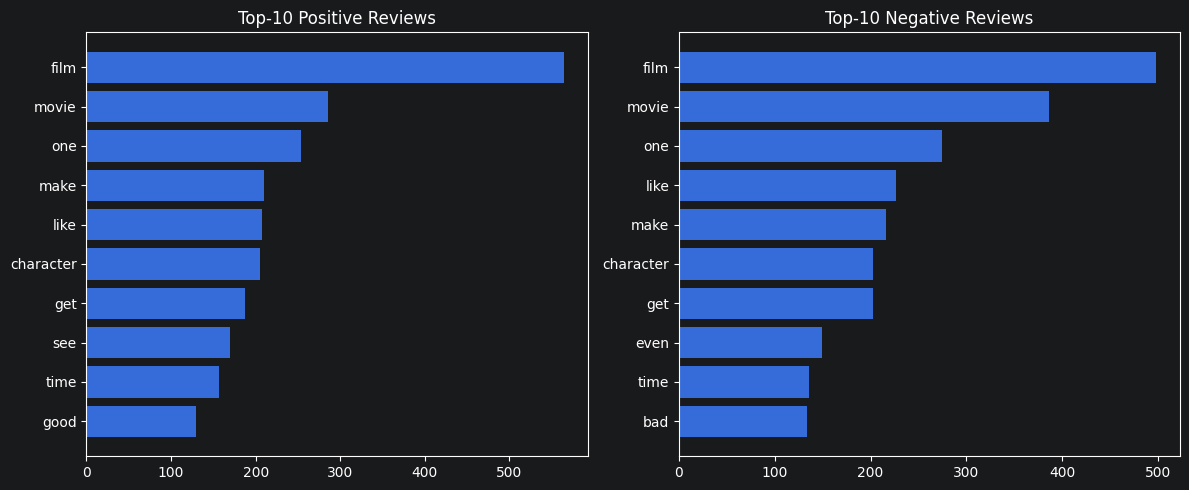

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Позитивні
words = [word for word, freq in pos_top10]
freqs = [freq for word, freq in pos_top10]

axes[0].barh(words, freqs)
axes[0].set_title("Top-10 Positive Reviews")
axes[0].invert_yaxis()

# Негативні
words = [word for word, freq in neg_top10]
freqs = [freq for word, freq in neg_top10]

axes[1].barh(words, freqs)
axes[1].set_title("Top-10 Negative Reviews")
axes[1].invert_yaxis()

plt.tight_layout()

plt.savefig("movie_review_top_words.png")

plt.show()